### ***1. Definición del problema***

  • Contexto del problema.

    Muchas enfermedades estan relacionadas directamente con mutaciones geneticas, como falta, alargamiento, encogimiento, duplicacion de cromosomas. Muchos niños crecen sin un cuidado o tratamiento adecuado ya que no se realizan las suficientes pruebas geneticas en el embarazo, ademas de considerar los cruces geneticos como un desencadente de las mismas dada la gran prevalencia actual de enfemedades de este tipo.
    
  • Objetivo del proyecto.

    Poder predecir la subclase de trastorno genetico de un paciente mediante el entrenamiento de datos medicos de niños con transtornos geneticos.

  • Pregunta de negocio o investigación.  

    ¿Existe correlacion entre los antecedentes geneticos, familiares y medicos en la presencia de alguna subclase de transtornos geneticos?

  • Justificación de la elección del dataset.

    Este dataset esta alojado en la plataforma Kaggle y es pertinenete para predecir factores clinicos que pueden ayudar a prevenir, tratar y curar enfemedades relacionadas con antecedentes geneticos y familiares. Lo he elegido porque tiene bastante relacion con la carrera que estudio (Ingenieria biologica) y con una materia de citogenetica que vi en semestres pasados.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### ***2. Obtención y comprensión de los datos***

In [8]:

from google.colab import files
uploaded =files.upload()

Saving train.csv to train (1).csv


In [9]:

df = pd.read_csv('train.csv')
df.head()

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


- Descripción de las variables

In [10]:
# Extraer la metadata de cada columna
tabla_variables = pd.DataFrame({
    'Variable': df.columns,
    'Descripción': ''  # Columna en blanco para llenar a mano
})

# Guardar la tabla en un archivo Excel para editar las descripciones fácilmente
tabla_variables.to_excel('diccionario_de_datos.xlsx', index=False)

In [11]:
from google.colab import files
uploaded =files.upload()

Saving diccionario_de_datos (1).xlsx to diccionario_de_datos (1) (1).xlsx


In [12]:
dfvariables = pd.read_excel('diccionario_de_datos (1) (1).xlsx')
dfvariables.head(45)

,Variable,Descripción
0,Patient Id,Numero de identificacion del paciente
1,Patient Age,Edad del paciente
2,Genes in mother's side,Representa un defecto genetico en la madre del...
3,Inherited from father,Representa un defecto genetico en el padre del...
4,Maternal gene,Representa un defecto genético en el lado mate...
5,Paternal gene,Representa un defecto genético en el lado pate...
6,Blood cell count (mcL),Representa el recuento de células sanguíneas d...
7,Patient First Name,Representa el nombre de pila del paciente
8,Family Name,Representa el apellido o apellido del paciente
9,Father's name,Representa el nombre del padre de un paciente


- Dimensiones del dataset.

In [13]:
df.shape

(22083, 45)

- Tipos de datos.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 45 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        22083 non-null  object 
 1   Patient Age                                       20656 non-null  float64
 2   Genes in mother's side                            22083 non-null  object 
 3   Inherited from father                             21777 non-null  object 
 4   Maternal gene                                     19273 non-null  object 
 5   Paternal gene                                     22083 non-null  object 
 6   Blood cell count (mcL)                            22083 non-null  float64
 7   Patient First Name                                22083 non-null  object 
 8   Family Name                                       12392 non-null  object 
 9   Father's name    

### ***3. Análisis Exploratorio de Datos (EDA)***

-  Estadísticas descriptivas.

In [15]:
df.describe(include='all')

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
count,22083,20656.000000,22083,21777,19273,22083,22083.000000,22083,12392,22083,...,19929,19935.000000,19938,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000,19937,19915
unique,22083,NaN,2,2,2,2,NaN,2524,6282,16368,...,2,NaN,4,NaN,NaN,NaN,NaN,NaN,3,9
top,PID0x9332,NaN,Yes,No,Yes,No,NaN,James,Smith,Clardie,...,Singular,NaN,slightly abnormal,NaN,NaN,NaN,NaN,NaN,Mitochondrial genetic inheritance disorders,Leigh syndrome
freq,1,NaN,13143,13133,10647,12508,NaN,420,157,6,...,9977,NaN,5128,NaN,NaN,NaN,NaN,NaN,10202,5160
mean,NaN,6.974148,NaN,NaN,NaN,NaN,4.898871,NaN,NaN,NaN,...,NaN,7.486224,NaN,0.592483,0.551886,0.536233,0.497747,0.461917,NaN,NaN
std,NaN,4.319475,NaN,NaN,NaN,NaN,0.199663,NaN,NaN,NaN,...,NaN,2.653393,NaN,0.491385,0.497313,0.498698,0.500007,0.498560,NaN,NaN
min,NaN,0.000000,NaN,NaN,NaN,NaN,4.092727,NaN,NaN,NaN,...,NaN,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,3.000000,NaN,NaN,NaN,NaN,4.763109,NaN,NaN,NaN,...,NaN,5.424703,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,7.000000,NaN,NaN,NaN,NaN,4.899399,NaN,NaN,NaN,...,NaN,7.477132,NaN,1.000000,1.000000,1.000000,0.000000,0.000000,NaN,NaN
75%,NaN,11.000000,NaN,NaN,NaN,NaN,5.033830,NaN,NaN,NaN,...,NaN,9.526152,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN


- Identificación de valores nulos.

In [16]:
df.isnull().sum()

,0
Patient Id,0
Patient Age,1427
Genes in mother's side,0
Inherited from father,306
Maternal gene,2810
Paternal gene,0
Blood cell count (mcL),0
Patient First Name,0
Family Name,9691
Father's name,0


- Detección de valores atípicos.

In [17]:
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = data[(data[columna] < lim_inf) | (data[columna] > lim_sup)]
    porcentaje = (len(outliers) / len(data)) * 100

    print(f"Columna '{columna}': {len(outliers)} outliers ({porcentaje:.2f}%)")
    return outliers

In [18]:
for columna in df.select_dtypes(include=['int64', 'float64']).columns:
    detectar_outliers_iqr(df, columna)

Columna 'Patient Age': 0 outliers (0.00%)
Columna 'Blood cell count (mcL)': 143 outliers (0.65%)
Columna 'Mother's age': 0 outliers (0.00%)
Columna 'Father's age': 0 outliers (0.00%)
Columna 'Test 1': 0 outliers (0.00%)
Columna 'Test 2': 0 outliers (0.00%)
Columna 'Test 3': 0 outliers (0.00%)
Columna 'Test 4': 0 outliers (0.00%)
Columna 'Test 5': 0 outliers (0.00%)
Columna 'No. of previous abortion': 0 outliers (0.00%)
Columna 'White Blood cell count (thousand per microliter)': 0 outliers (0.00%)
Columna 'Symptom 1': 0 outliers (0.00%)
Columna 'Symptom 2': 0 outliers (0.00%)
Columna 'Symptom 3': 0 outliers (0.00%)
Columna 'Symptom 4': 0 outliers (0.00%)
Columna 'Symptom 5': 0 outliers (0.00%)


- Visualizaciones relevantes.

    * Visualizar la frecuencia de cada diagnóstico para detectar desbalance de clases.

/tmp/ipykernel_2964/3001695687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Genetic Disorder', ax=axes[0], palette='viridis')
/tmp/ipykernel_2964/3001695687.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Disorder Subclass', ax=axes[1], palette='magma')


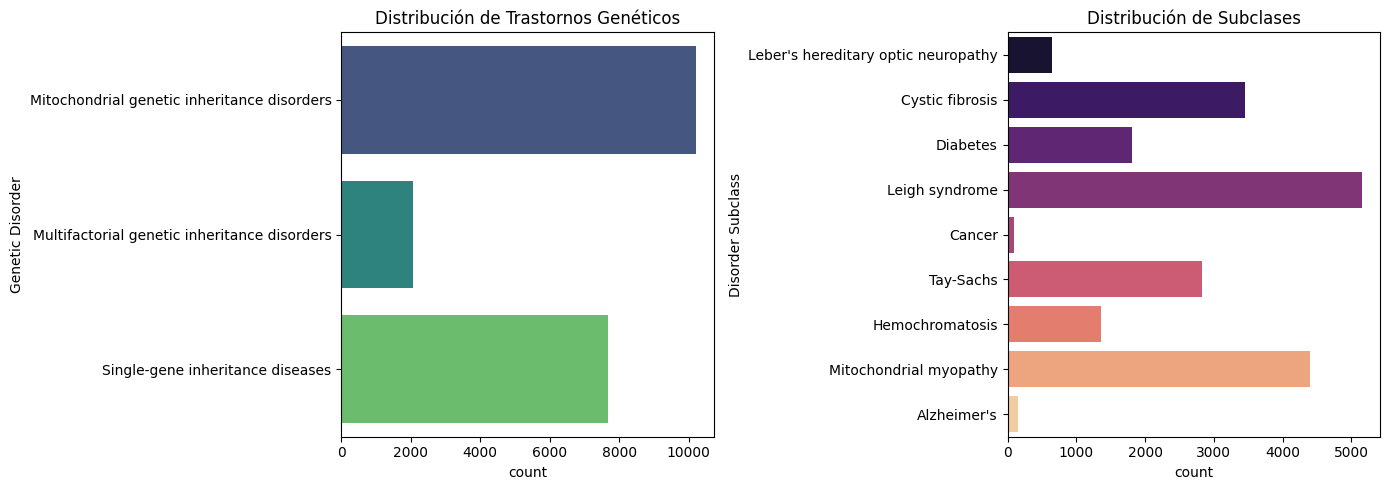

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y='Genetic Disorder', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Trastornos Genéticos')

sns.countplot(data=df, y='Disorder Subclass', ax=axes[1], palette='magma')
axes[1].set_title('Distribución de Subclases')

plt.tight_layout()
plt.show()

    *Vizualizacion de matriz de nulos para identificar si los valores nulos siguen un patron sistematico o faltan al azar
  

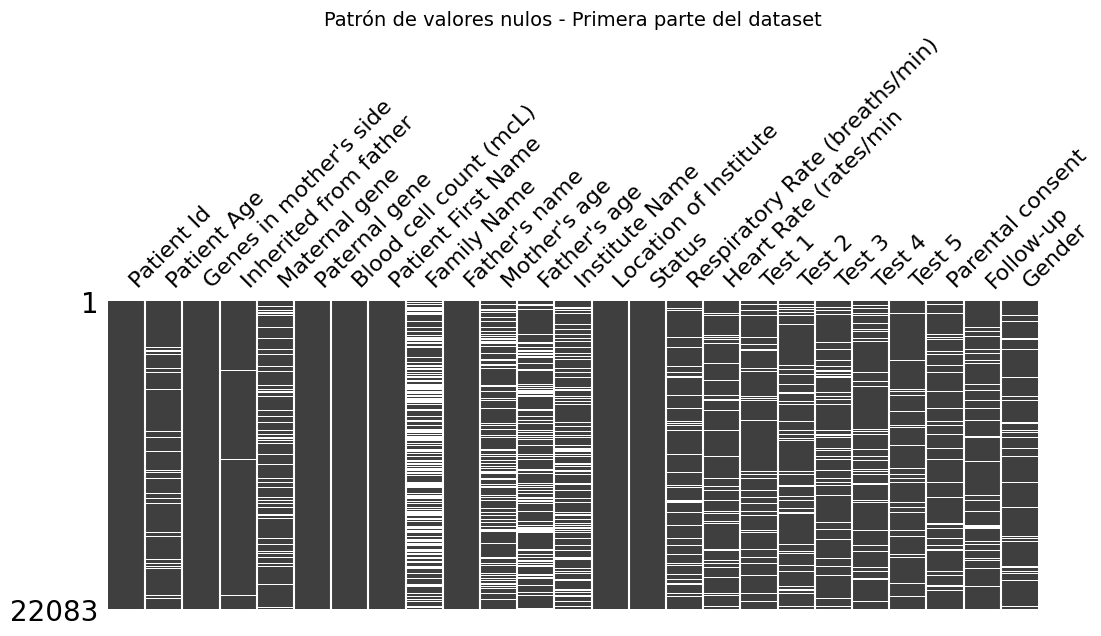

In [20]:
import missingno as msno

# Visualizar el patrón de nulos en las primeras 25 variables
msno.matrix(df.iloc[:, :25], figsize=(12, 4), sparkline=False)
plt.title('Patrón de valores nulos - Primera parte del dataset', fontsize=14)
plt.show()

<Figure size 1400x500 with 0 Axes>

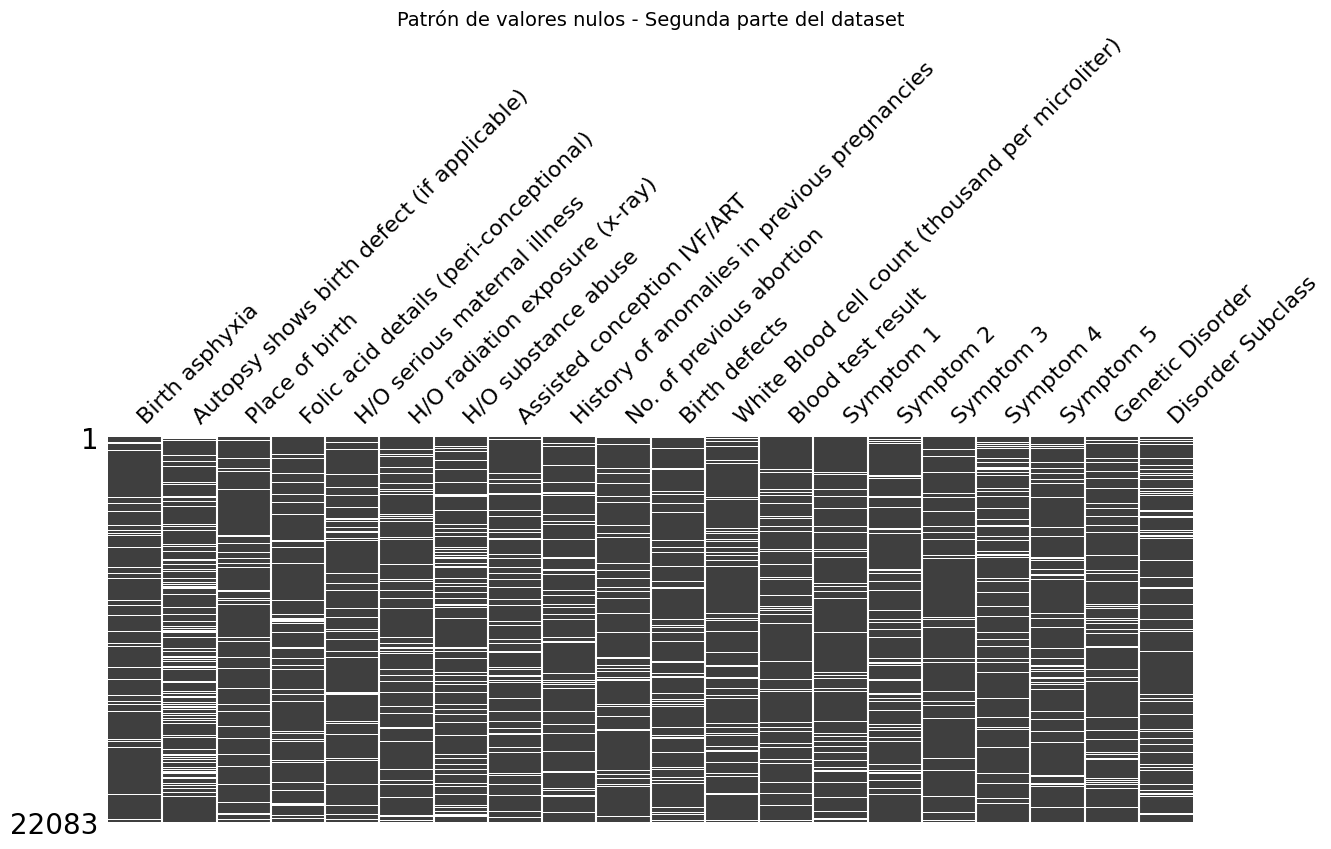

In [21]:
# Visualizar el patrón de nulos de la columna 25 hasta el final
plt.figure(figsize=(14, 5))
msno.matrix(df.iloc[:, 25:], figsize=(14, 5), sparkline=False)
plt.title('Patrón de valores nulos - Segunda parte del dataset', fontsize=14)
plt.show()

    *Evaluar el peso de variables hereditarias y resultados de examen de sangre sobre la prediccion

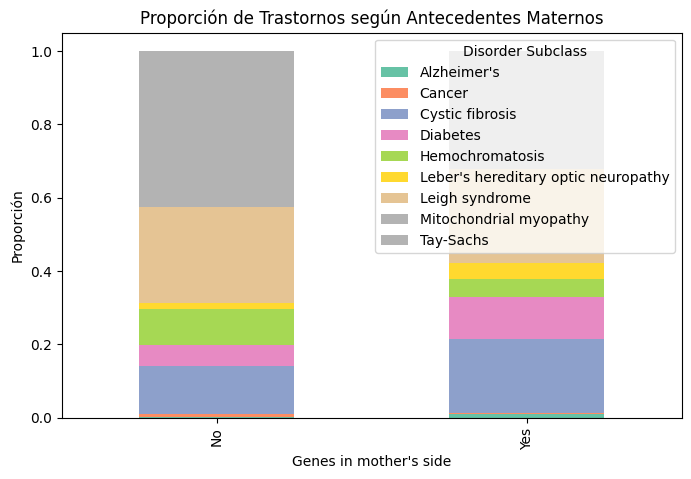

In [22]:
pd.crosstab(df["Genes in mother's side"], df['Disorder Subclass'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(8, 5), colormap='Set2'
)
plt.title('Proporción de Trastornos según Antecedentes Maternos')
plt.ylabel('Proporción')
plt.show()

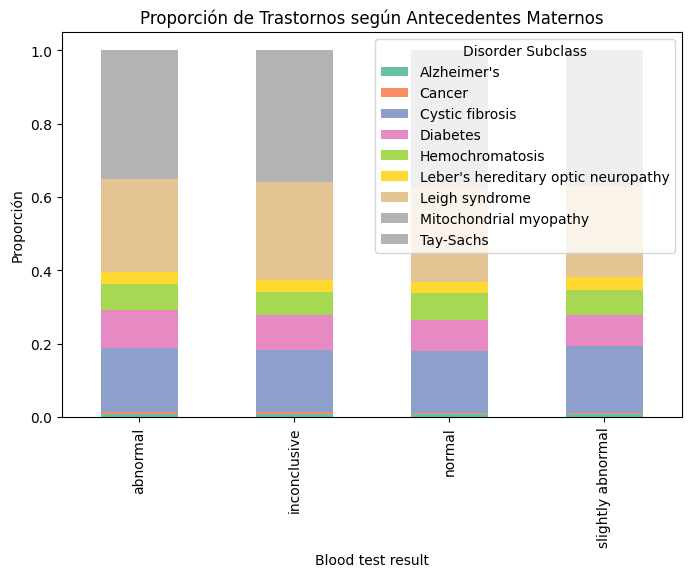

In [23]:
pd.crosstab(df["Blood test result"], df['Disorder Subclass'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(8, 5), colormap='Set2'
)
plt.title('Proporción de Trastornos según Antecedentes Maternos')
plt.ylabel('Proporción')
plt.show()

- Evaluar la distribuccion de los resultados de conteo de celulas sanguineas y el impacto en cada tipo de subclase de trastorno

/tmp/ipykernel_2964/2352054587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Disorder Subclass', y='Blood cell count (mcL)', palette='Set3')


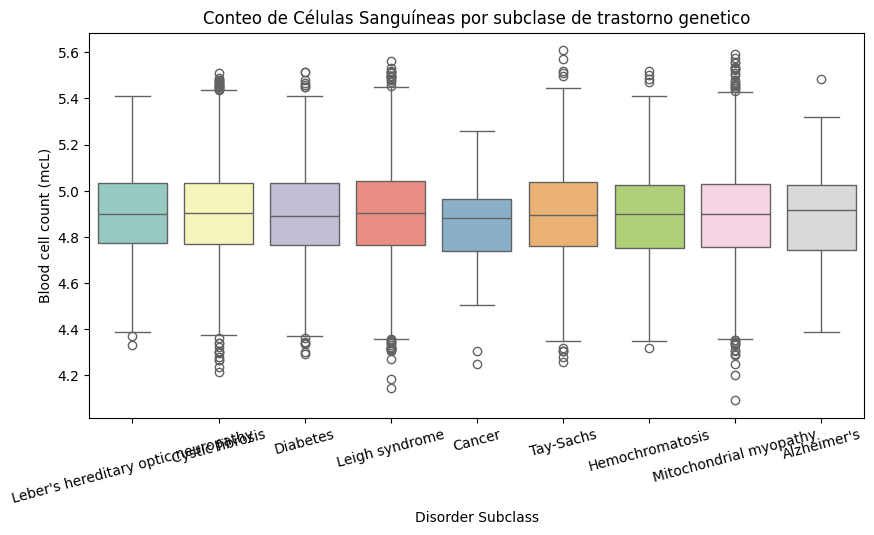

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Disorder Subclass', y='Blood cell count (mcL)', palette='Set3')
plt.title('Conteo de Células Sanguíneas por subclase de trastorno genetico')
plt.xticks(rotation=15)
plt.show()

    * Identificar la distribucion de los test 1 al 5 para determinar su usabilidad

,min,mean,50%,max,std
Test 1,0.0,0.0,0.0,0.0,0.0
Test 2,0.0,0.0,0.0,0.0,0.0
Test 3,0.0,0.0,0.0,0.0,0.0
Test 4,1.0,1.0,1.0,1.0,0.0
Test 5,0.0,0.0,0.0,0.0,0.0


/tmp/ipykernel_2964/131288223.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tests_melt, x='Prueba', y='Resultado', palette='Set2')


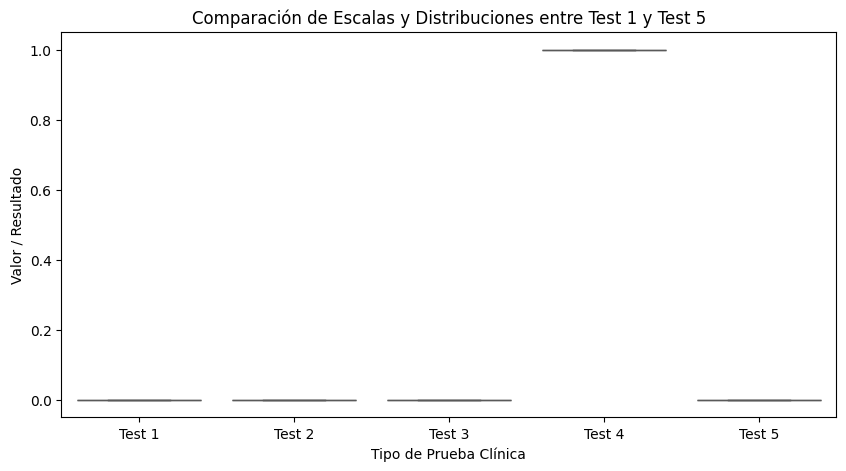

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inspección numérica rápida (min, media, max)
cols_test = ['Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5']
display(df[cols_test].describe().T[['min', 'mean', '50%', 'max', 'std']])

# 2. Reestructurar datos para graficar todos los tests juntos
df_tests_melt = df.melt(value_vars=cols_test, var_name='Prueba', value_name='Resultado')

# 3. Graficar la distribución comparativa
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_tests_melt, x='Prueba', y='Resultado', palette='Set2')
plt.title('Comparación de Escalas y Distribuciones entre Test 1 y Test 5', fontsize=12)
plt.xlabel('Tipo de Prueba Clínica', fontsize=10)
plt.ylabel('Valor / Resultado', fontsize=10)
plt.show()

In [26]:
# 1. Confirmar cantidad de valores únicos (debería dar 1 para cada una)
print(df[['Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5']].nunique())

Test 1    1
Test 2    1
Test 3    1
Test 4    1
Test 5    1
dtype: int64


    * Mapa de calor de densidad para encontrar perfiles clinicos

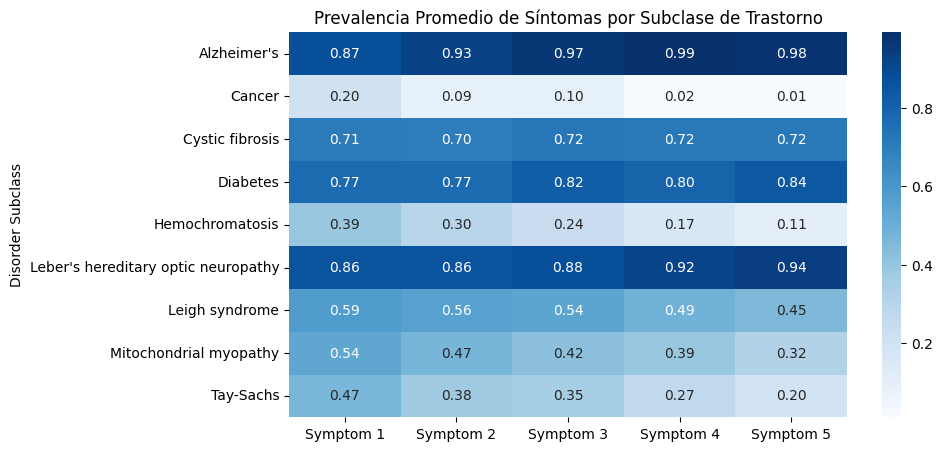

In [27]:
# Promedio de síntomas por subclase
sintomas = ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
perfil_sintomas = df.groupby('Disorder Subclass')[sintomas].mean()

plt.figure(figsize=(9, 5))
sns.heatmap(perfil_sintomas, annot=True, cmap='Blues', fmt='.2f')
plt.title('Prevalencia Promedio de Síntomas por Subclase de Trastorno')
plt.show()

- Hallazgos principales.
---
  


En primer lugar la mayoría de variables numéricas esta en flotante cuando únicamente es necesario que lo esten White Blood cell count (thousand per microliter) y Blood cell count (mcL), en segundo lugar hay bastantes variables que según su descripción no aportan datos biológicos relevantes para la predicción, en tercer lugar se ha identificado bastantes variables con valores nulos, sin embargo mediante la visualización de estos, se encontró que no siguen un patron estructural sino aleatorio lo que implica la posibilidad de manejar estos valores faltantes con medidas estadísticas que los representen ya que lo que pudo haber ocurrido fue omisiones aleatorias en los registros o falta de aplicar pruebas, por eso esas variables numéricas se pueden arreglar. Sin emabargo es posible eliminar columnas que además de no aportar valor biológico contienen nulos. Asi mismo para variables categoricas la mejor opcion sera usar valor desconocido para ver si hay relevancia medica en la aplicacion o no de un test por ejemplo. En cuarto lugar se identifico que la única columna con valores atípicos fue Blood cell count (mcL), y ademas tenia valor predictivo la subclase del trastorno. En quinto lugar se encontró una distribución desbalanceada de los trastornos genéticos y las subclases, lo cual nos da indicaciones importantes para evaluar las métricas de evaluación que proporcionen los modelos, en este caso tiene mas peso el F1-Score que la precisión ya que el modelo puede estar siendo permeado por la alta dispocion de unos datos sobre otros. Por último se ha visto que el peso predictivo de variables hereditarias como Genes in mother's side es alto en la subclase del transtorno. Por otro lado el resultado de sangre parece no tener tanto valor predictivo en la varible objetivo.

### ***4. Preparación de datos***

- Limpieza de datos.

In [28]:
#Eliminar columnas incesesarias para el modelo de ML
df = df.drop(columns=["Patient Id", "Patient First Name", "Family Name", "Father's name", "Mother's age", "Father's age", "Institute Name", "Location of Institute", "Status", "Parental consent", "Follow-up", "Genetic Disorder"])

In [29]:
#Eliminar las columnas por varianza cero para que no hagan ruido
cols_sin_varianza = ['Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5']
df = df.drop(columns=cols_sin_varianza)

- Corregir tipos de datos incorrectos

In [30]:
# Corregir tipos de datos incorrectos

df["Patient Age"] = pd.to_numeric(df["Patient Age"], errors="coerce").astype("Int64")
df["No. of previous abortion"] = pd.to_numeric(df["No. of previous abortion"], errors="coerce").astype("Int64")
for i in range(1, 6):
    df[f"Symptom {i}"] = pd.to_numeric(df[f"Symptom {i}"], errors="coerce").astype("Int64")


- Tratamiento de valores faltantes.

In [31]:
for col in df.columns:
    # Evaluar únicamente las columnas que contengan valores nulos
    if df[col].isnull().any():

        # Evaluar si la columna es categórica o de texto
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')

In [32]:
#Identificar columnas a las que se le pueden aplicar representaciones estadisticas
cols_mediana = [
    'Patient Age',
    'White Blood cell count (thousand per microliter)',
    'No. of previous abortion'
]

for col in cols_mediana:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Síntomas binarios (0 y 1) -> Moda
cols_sintomas = [f'Symptom {i}' for i in range(1, 6)]

for col in cols_sintomas:
    if col in df.columns:
        moda_val = df[col].mode()[0]
        df[col] = df[col].fillna(moda_val)

In [33]:
#Eliminar los registros que no contengan la varible objetivo que es lo que vamos a entrenar
df = df[df['Disorder Subclass'].notnull() & (df['Disorder Subclass'] != 'Unknown')].reset_index(drop=True)

- Ingenieria de caracteristicas

In [34]:
# Suma de síntomas activos por paciente (valor de 0 a 5)
cols_sintomas = [f'Symptom {i}' for i in range(1, 6)]
df['Total_Symptoms'] = df[cols_sintomas].sum(axis=1)

In [35]:
# Crea una bandera binaria (1 si ambos padres transmiten antecedente, 0 en otro caso)
df['Double_Inheritance_Risk'] = (
    (df["Genes in mother's side"] == 'Yes') &
    (df['Inherited from father'] == 'Yes')
).astype(int)

In [36]:
# Crear una bandera para niveles elevados de glóbulos blancos (> 10)
df['High_WBC_Flag'] = (df['White Blood cell count (thousand per microliter)'] > 10).astype(int)

Se creó la característica binaria High_WBC_Flag ($>10 \times 10^3/\mu L$) basada en el límite fisiológico estándar de leucocitosis. Esta transformación permite al modelo identificar de forma explícita a los pacientes que presentan una respuesta inflamatoria o inmunológica elevada, convirtiendo una medición continua en un indicador clínico directo de alto valor predictivo.

- División entrenamiento/prueba.

In [37]:
from sklearn.preprocessing import LabelEncoder

# Separar la variable objetivo 'y' antes de hacer get_dummies
y_raw = df['Disorder Subclass']
X_raw = df.drop(columns=['Disorder Subclass'])

# 2. Aplicar One-Hot Encoding a la matriz de características X
X = pd.get_dummies(X_raw, drop_first=True)

# 3. Codificar 'y' como una sola columna de números enteros (0, 1, 2...)
le = LabelEncoder()
y = le.fit_transform(y_raw)

In [38]:
# Separar la parte a entrenar y la evaluativa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Escalamiento o normalización.

In [39]:
# Normalizar unicamente columnas con valores numericos no binarios
cols_continuas = [
    'Patient Age',
    'White Blood cell count (thousand per microliter)',
    'Blood cell count (mcL)',
    'Total_Symptoms',
    'No. of previous abortion'
]

scaler = StandardScaler()
X_train[cols_continuas] = scaler.fit_transform(X_train[cols_continuas])
X_test[cols_continuas] = scaler.transform(X_test[cols_continuas])

In [40]:
X_train.head()

,Patient Age,Blood cell count (mcL),No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Total_Symptoms,...,Assisted conception IVF/ART_Unknown,Assisted conception IVF/ART_Yes,History of anomalies in previous pregnancies_Unknown,History of anomalies in previous pregnancies_Yes,Birth defects_Singular,Birth defects_Unknown,Blood test result_abnormal,Blood test result_inconclusive,Blood test result_normal,Blood test result_slightly abnormal
4337,-1.184533,1.195696,-1.493036,-0.383456,1,0,1,0,0,-0.604310,...,False,False,False,False,False,False,False,False,True,False
2457,0.490233,-2.239714,-1.493036,0.095420,0,1,0,0,0,-1.499343,...,False,False,False,False,False,False,False,False,False,False
14826,-0.466776,-0.322794,-0.002899,-1.274711,1,0,1,1,0,0.290723,...,False,False,False,False,True,False,False,False,True,False
16374,0.011728,-0.029229,-0.747968,1.786279,0,1,1,0,0,-0.604310,...,False,True,False,False,False,False,True,False,False,False
6399,0.011728,-0.774799,1.487237,0.818920,0,0,0,1,0,-1.499343,...,True,False,False,False,False,False,True,False,False,False


### ***5. Modelado Aprendizaje Supervisado***

- Metricas adecuadas

In [41]:
# Ajuste hiperparametros
parametros = {
    'log_reg': (LogisticRegression(max_iter=200, solver = 'lbfgs'), {'C': [0.01, 0.1, 1, 10]}),
    'arbol_decision': (DecisionTreeClassifier(random_state=42), {'max_depth' : [2, 4, 6, 8, 10]})
}

In [42]:
mejores_modelos = {}

for name, (modelo, params) in parametros.items():

    print(f"\nBuscando mejores hiperparámetros para {name}...")

    grid = GridSearchCV(
        modelo,
        params,
        cv=4,
        scoring='f1_macro'
    )

    grid.fit(X_train, y_train)

    print("Mejores parámetros:", grid.best_params_)

    mejor_modelo = grid.best_estimator_

    y_pred = mejor_modelo.predict(X_test)

    f1_macro = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    print(f"F1-macro en test: {f1_macro:.4f}")

    mejores_modelos[name] = {

        'model': mejor_modelo,

        'f1_macro': f1_macro,

        'params': grid.best_params_
    }


Buscando mejores hiperparámetros para log_reg...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Mejores parámetros: {'C': 10}
F1-macro en test: 0.3396

Buscando mejores hiperparámetros para arbol_decision...
Mejores parámetros: {'max_depth': 8}
F1-macro en test: 0.2703


- **Primer modelo: Regression logistica**

In [43]:
# Regresion logistica
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, C=10) #se usan 1000 iteraciones para asegurar la convergencia
log_reg.fit(X_train, y_train) #aprendemos el modelo con los datos de entrenamiento
y_pred_log = log_reg.predict(X_test) # tomar el modelo aprendido y predecir con los datos de prueba

In [44]:
#matriz de confusion
matriz_confusion = confusion_matrix(y_test, y_pred_log)
print("Matriz de confusión:")
print(matriz_confusion)

Matriz de confusión:
[[ 16   0   1   4   0   8   0   0   0]
 [  0  14   0   0   4   0   0   0   1]
 [ 54   0 264 139   1  88 126  25   7]
 [ 62   1 101  96   2  84  27  10   4]
 [  0  56   0   0 124   0  11  20  64]
 [ 52   0  16  34   0  33   2   0   0]
 [  8  12 187  38  39  10 382 222  99]
 [  1  25  60   6 111   3 259 227 179]
 [  0  44   4   5 166   0  78 106 161]]


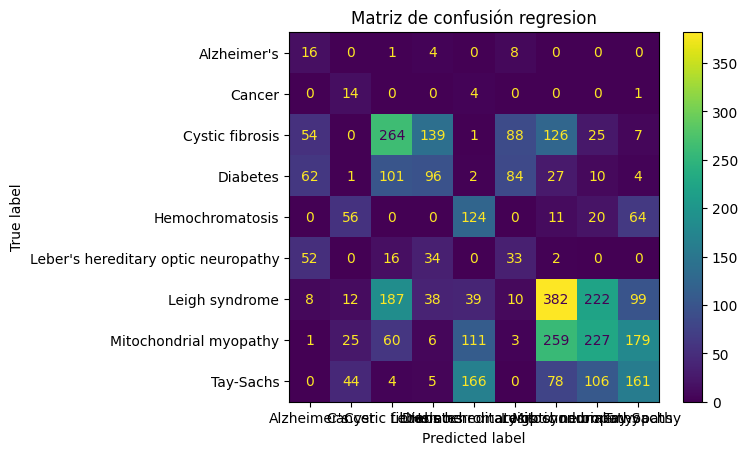

0.3306552849610846
              precision    recall  f1-score   support

           0       0.08      0.55      0.14        29
           1       0.09      0.74      0.16        19
           2       0.42      0.38      0.39       704
           3       0.30      0.25      0.27       387
           4       0.28      0.45      0.34       275
           5       0.15      0.24      0.18       137
           6       0.43      0.38      0.41       997
           7       0.37      0.26      0.31       871
           8       0.31      0.29      0.30       564

    accuracy                           0.33      3983
   macro avg       0.27      0.39      0.28      3983
weighted avg       0.36      0.33      0.34      3983



In [45]:
# mapa de calor
mapa_calor_confusion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=le.classes_)
mapa_calor_confusion.plot()
plt.title("Matriz de confusión regresion")
plt.show()

# para evealuar
print(accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

- **Segundo modelo: Arbol de desicion**

In [46]:
#arbol de decision
arbol_decision = DecisionTreeClassifier(class_weight='balanced', max_depth=8) #8 arboles
arbol_decision.fit(X_train, y_train)
y_pred_arbol = arbol_decision.predict(X_test)

In [47]:
#Matriz de desicion
arbol_matriz_confusion = confusion_matrix(y_test, y_pred_arbol)
print("Matriz de confusión:")
print(arbol_matriz_confusion)

Matriz de confusión:
[[ 10   0   1   2   0  16   0   0   0]
 [  0  11   0   0   6   0   0   0   2]
 [ 37   0 287  87   4 110 152  17  10]
 [ 47   2 122  58   2 107  38   4   7]
 [  0  73   1   0 109   3  14  15  60]
 [ 37   0  31  16   0  52   1   0   0]
 [  8  15 162  21  54  20 427 163 127]
 [  1  47  56   3 130   6 269 172 187]
 [  1  71  11   1 154   3  75  91 157]]


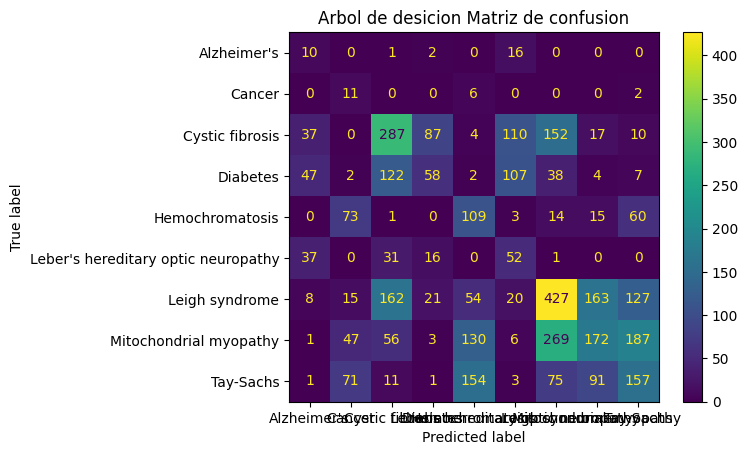

0.3221190057745418
              precision    recall  f1-score   support

           0       0.07      0.34      0.12        29
           1       0.05      0.58      0.09        19
           2       0.43      0.41      0.42       704
           3       0.31      0.15      0.20       387
           4       0.24      0.40      0.30       275
           5       0.16      0.38      0.23       137
           6       0.44      0.43      0.43       997
           7       0.37      0.20      0.26       871
           8       0.29      0.28      0.28       564

    accuracy                           0.32      3983
   macro avg       0.26      0.35      0.26      3983
weighted avg       0.36      0.32      0.33      3983



In [48]:
# Mapa de calor
mapa_calor_confusion = ConfusionMatrixDisplay(confusion_matrix=arbol_matriz_confusion, display_labels=le.classes_)
mapa_calor_confusion.plot()
plt.title("Arbol de desicion Matriz de confusion")
plt.show()

# Para evaluar
print(accuracy_score(y_test, y_pred_arbol))
print(classification_report(y_test, y_pred_arbol))

- *Comparación de resultados.*

La Regresión Logística logra mejores resultados en los tests. Mejor manejo de Clases Minoritarias (Clases 0 y 1). El Macro F1-Score de la Regresión Logística ($0.33$ vs. $0.27$) refleja que es un modelo más consistente evaluando todas las subclases por igual, sin ignorar las menos frecuentes. Regresión Logística es el modelo ganador. Presenta un mejor comportamiento lineal en un espacio con múltiples características y evita mejor el sobreajuste ante datos con ruido y desbalance de clases como en este caso.

- *Evaluación*

    • Métricas utilizadas.
      Se usaron las metricass de C=10 y 8 arboles de desiccion ya que fueron los parametros que mejor rendimiento dieron en la pruebas de ajuste de hiperparametros
    • Interpretación de resultados.
      El mejor modelo es el de regresion logistica, logro mejores resultados en el f1-score que tiene mas peso en este caso por el desbalance de clases
    • Limitaciones del modelo.
      Como las clases minoritarias tenian un F1-score muy bajo se uso el balanceo de clases por pesos y esto aunque disminuyo la presicion aumento el recall de las clases minoritarias que en diagnóstico médico, por lo general es preferible mantener el balanceo. Es clínicamente más grave no detectar a un paciente con una condición rara que enviar a un paciente sano o con otra condición a exámenes confirmatorios adicionales.
    • Posibles mejoras.
      Hace falta mejorar el rendimiento quiza introducciendo mas registros que comprendan esos datos minoritarios para dar mejores resultados predictivos, ademas es posible que usar un modelo mas robusto con meyores niveles, pueda ocacionar que se detecten mejor las enfermedades

7. *Conclusiones*

    • ¿Se cumplió el objetivo?
      No, el modelo sirve para predecir las enfermedades pero en muy pocos casos acierta, por supuesto requiere mejoras e inlcuso puede que buscar otros modelos para mejorar su usabilidad
    • ¿Qué hallazgos relevantes se encontraron?
      Hay un desbalanbce de clases que hace oportuno un balanceo de pesos en el modelo para poder encontrar los casos mas raros y no permitir un mal diagnostico medico, aunque el modelo no es usable, esto nos podria permitir mejorar otros posibles modelos
    • ¿Qué valor aportaría este proyecto a una organización?
      Ayudaria a predecir enfermedades geneticas en niños, introduccionedo un cultura de cuidado y mejor tratamiento dado un mejor diagnostico mediante pruebas geneticas en la etapa del embarazo y para tener mejores cuidados con las condiciones del nacimiento inclusive.